## Statistical and Machine Learning, Fall 2024

### Week 14: Implementing Recurrent Neural Networks using Keras		

### Instructor: Farhad Pourkamali 

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-pourkamali/MATH6388Online/blob/main/Week14.ipynb)



### Introduction
<hr style="border:2px solid gray">

* A key characteristic of all the neural networks we have explored so far, such as densely connected networks and convolutional networks, is that they lack memory.

    * Each input presented to these networks is processed independently, with no *state* retained between samples.


* This lack of memory means they cannot leverage information from previous inputs, making them unsuitable for tasks that require understanding context over time, such as time-series or sequential data.

* A recurrent neural network (RNN) processes sequences by iterating through elements and maintaining a state that retains information about what it has seen so far.
    * Essentially, an RNN is a type of neural network with an internal loop, allowing it to handle sequential data effectively.
    
    <img src="https://github.com/farhad-pourkamali/MATH6388Online/blob/main/images/RNN1.png?raw=true" width=500>
    
* To clarify the concepts of loop and state, let us consider the forward pass of a simple RNN. This RNN takes as input a rank-2 tensor of size ```(num_timesteps, num_features)```. It loops over timesteps, and at each timestep, it considers its current state at ```t``` and the input at ```t``` (of shape ```(num_features,)```), combining them to obtain the output at ```t```.

*  Each "unrolled" layer represents the RNN's computations at a particular timestep, showing how the hidden state and output are updated at each step. 
    * The hidden state from the previous timestep is fed into the next timestep along with the new input.

    $$\mathbf{h}_t=f(\mathbf{x}_t, \mathbf{h}_{t-1}),\;\;y_t=g(\mathbf{h}_t)$$


<img src="https://github.com/farhad-pourkamali/MATH6388Online/blob/main/images/time.png?raw=true" width=350>



### Keras Implementation
<hr style="border:2px solid gray">


* Recall that we work with batches of samples not just a single sample, thus the input to an RNN model is a rank-3 tensor of size ```(num_samples, num_timesteps, num_features)```.

* The `SimpleRNN` layer is a type of recurrent neural network (RNN) layer provided by deep learning frameworks such as Keras.

* `units=50` specifies that the SimpleRNN layer has 50 neurons.

```Python 
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense

model = Sequential()
model.add(SimpleRNN(units=50, input_shape=(num_timesteps, num_features)))
model.add(Dense(units=1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy')
model.summary()

```

* Can you calculate the number of trainable parameters in the given Keras model?

In [1]:
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense

num_timesteps = 100
num_features = 10

model = Sequential()
model.add(SimpleRNN(units=50, input_shape=(num_timesteps, num_features)))
model.add(Dense(units=1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy')
model.summary()

/Users/farhad/anaconda3/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         3,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,101 (12.11 KB)

 Trainable params: 3,101 (12.11 KB)

 Non-trainable params: 0 (0.00 B)

* SimpleRNN Layer
    * params = 50×(10+50+1)=50×61=3050
* Dense Layer
    * params = (50×1)+1=50+1=51

### Mathematical Expression
<hr style="border:2px solid gray">

* Output of a recurrent layer for a single instance can be written as 

$$ \phi\big(\mathbf{W}_{hx} \mathbf{x}_t + \mathbf{W}_{hh} \mathbf{h}_{t-1}+\mathbf{b}\big)$$

* Hence, in the above example, we have $\mathbf{W}_{hx}\in\mathbb{R}^{50\times 10}$, $\mathbf{W}_{hh}\in\mathbb{R}^{50\times 50}$, $\mathbf{b}\in\mathbb{R}^{50}$

* For the remainder of this lecture, we will assume that the bias term is not present to simplify the notation.


### Backpropagation through time
<hr style="border:2px solid gray">

* Backpropagation Through Time (BPTT) is a training algorithm used for RNNs to update the weights based on the error gradient. It extends the standard backpropagation algorithm to handle the sequential nature of RNNs.

* We can compute the maximum likelihood estimate of the parameters for an RNN by solving 

$$
\theta^* = \arg\max_{\theta} p(y_{1:T} \mid x_{1:T}, \theta),
$$

assuming a single training sequence for notational simplicity. To compute the MLE, we need to calculate the gradients of the loss with respect to the parameters.

* More precisely, consider the following model:

$$\mathbf{h}_t=\mathbf{W}_{hx}\mathbf{x}_t+\mathbf{W}_{hh}\mathbf{h}_{t-1}$$
$$y_t = \mathbf{W}_{ho}\mathbf{h}_t$$
$$L = \frac{1}{T}\sum_{t=1}^Tl(y_t^{ref}, y_t)$$

* We made a few assumptions here, such as omitting the constant term and activation functions, to simply illustrate how adding the "recurrent connection" (i.e., $\mathbf{W}_{hh}\mathbf{h}_{t-1}$) impacts the gradient computation.

* To this end, let us vectorize or flatten the weight matrices involved. We define the vector $\mathbf{w}_h$ to represent $\mathbf{W}_{hx}$ and $\mathbf{W}_{hh}$. Similarly, $\mathbf{w}_o$ represents the flattened version of $\mathbf{W}_{ho}$. Hence, we get the following:

$$\mathbf{h}_t=f\big(\mathbf{x}_t, \mathbf{h}_{t-1}, \mathbf{w}_h\big)$$
$$y_t=g\big(\mathbf{h}_t, \mathbf{w}_o\big)$$

* Next, we focus on computing $\frac{\partial L}{\partial \mathbf{w}_h}$ using the chain rule

\begin{align}
\frac{\partial L}{\partial \mathbf{w}_h} &= \frac{1}{T}\sum_{t=1}^T \frac{\partial l(y_t^{ref}, y_t)}{\partial \mathbf{w}_h} \\ &= \frac{1}{T}\sum_{t=1}^T \frac{\partial l(y_t^{ref}, y_t)}{\partial y_t} \frac{\partial g\big(\mathbf{h}_t, \mathbf{w}_o\big)}{\partial \mathbf{h}_t} \frac{\partial \mathbf{h}_t}{\partial \mathbf{w}_h}
\end{align}

* The first and second terms are easy, since they are  local to each timestep. However, the last term depends on the hidden state, and thus require working backwards in time:

\begin{align}
\frac{\partial \mathbf{h}_t}{\partial \mathbf{w}_h}=&\frac{\partial f(\mathbf{x}_t,\mathbf{h}_{t-1}, \mathbf{w}_h)}{\partial \mathbf{w}_h }\\
&+ \frac{\partial f(\mathbf{x}_t,\mathbf{h}_{t-1}, \mathbf{w}_h)}{\partial \mathbf{h}_{t-1}}\frac{\partial \mathbf{h}_{t-1}}{\partial \mathbf{w}_h}
\end{align}

* Thus, computing this gradient requires recursive operations to traverse backward in time.
The nice thing is that deep learning libraries have implemented this type of backpropagation.


### Going from a SimpleRNN to an LSTM
<hr style="border:2px solid gray">

* RNNs with a sufficient number of hidden units have the theoretical capability to remember inputs from long in the past.

* However, in practice, "vanilla" RNNs often fail to remember long-term dependencies due to the vanishing gradient problem. This issue occurs when gradients used to update the network's weights become very small, making it difficult for the network to learn and retain information over long sequences.

* Long Short Term Memory (LSTM) networks are a type of RNN designed to overcome the vanishing gradient problem.

* Key Components of LSTMs:

    * Cell State: LSTMs have a cell state that runs through the entire sequence, allowing information to flow through the network with minimal changes.
    * Gates: LSTMs use three gates to regulate the flow of information:
        * Forget Gate: Decides what information to discard from the cell state.
        * Input Gate: Determines which new information to add to the cell state.
        * Output Gate: Controls what information to output based on the cell state.
        
* Here is an illustration
    * The forget gate uses a sigmoid activation to determine how much of the previous cell state should be forgotten. 
        * Output values close to 0 mean that the corresponding information should be largely forgotten, while values close to 1 mean that the information should be retained.
    
    * The input gate uses a sigmoid activation to decide how much of the new input should be written to the cell state. 
        * This gate’s output controls the extent to which the new information impacts the cell state, with values close to 0 preventing most of the new input from being added and values close to 1 allowing it to be added fully.
    
    * The output gate uses a sigmoid activation to determine how much of the cell state should be exposed to the next hidden state.
        * This gate modulates the cell state’s contribution to the output, with values close to 0 reducing the output’s influence and values close to 1 increasing it.
        
        <img src="https://github.com/farhad-pourkamali/MATH6388Online/blob/main/images/LSTM.png?raw=true" width=550>

* Let us create a synthetic data set to test the performance of RNNs

- Input Data $X$
    * Shape: (num_samples, num_steps,1)
    * num_samples: Number of sequences (e.g., 2000).
    * num_steps: Length of each sequence (e.g., 100).
    * Each value in the sequence is drawn from a uniform random distribution $U(0,1)$
    
- Output data $Y$ is derived from $X$ by applying two transformations
    * Cumulative Sum, for a single sequence $X[i, :, 0]$ 
    \begin{equation}
    \text{cumsum}[i, j] = \sum_{k=0}^j X[i, k, 0], \quad \forall j \in [0, \text{num_steps}-1]
    \end{equation}
    * Non-linear Transformation ($\sin$)
    \begin{equation}
      Y[i, j] = \sin\left(0.05 \cdot \text{cumsum}[i, j]\right)
    \end{equation}
    
*  Each element in $Y[i, j]$ depends on all previous elements of $X[i, :, 0]$ up to $j$, making this a sequential data generation process.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def generate_smooth_data(num_samples=2000, num_steps=100):
    X = np.random.rand(num_samples, num_steps, 1)  # Generate random input sequences
    Y = np.sin(0.05*np.cumsum(X, axis=1))  # Apply a non-linear transformation on the cumulative sum
    return X, Y

X, y = generate_smooth_data()


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_train.shape)

(1600, 100, 1) (1600, 100, 1)


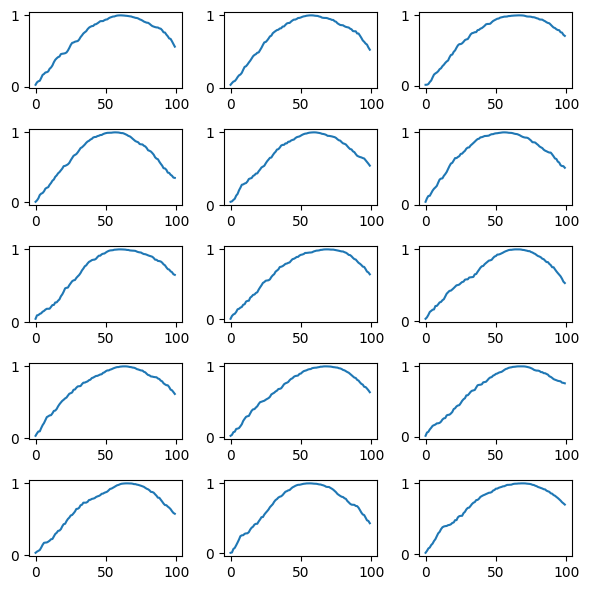

In [4]:
import matplotlib.pyplot as plt

n_rows = 5
n_cols = 3

fig, axs = plt.subplots(n_rows, n_cols, figsize=(6, 6))

ind_selected = np.random.choice(len(X_train), n_rows*n_cols)

# Iterate through the grid and create a subplot in each position
for i in range(n_rows):
    for j in range(n_cols):
        axs[i, j].plot(y[ind_selected[i * n_cols + j]].ravel())
        
plt.tight_layout()
plt.show()


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Define model architecture
model = Sequential([
    SimpleRNN(10, return_sequences=True, input_shape=(None, 1)),  
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0)


/Users/farhad/anaconda3/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, None, 10)       │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, None, 1)        │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - loss: 1.0085
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - loss: 0.1688
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - loss: 0.0694
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - loss: 0.0584
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - loss: 0.0422
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - loss: 0.0255
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - loss: 0.0207
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - loss: 0.0188
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - loss: 0.0381
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - loss: 0.0236


In [6]:
# Test the model 
y_pred = model.predict(X_test)

y_pred.shape

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 218ms/step


(400, 100, 1)

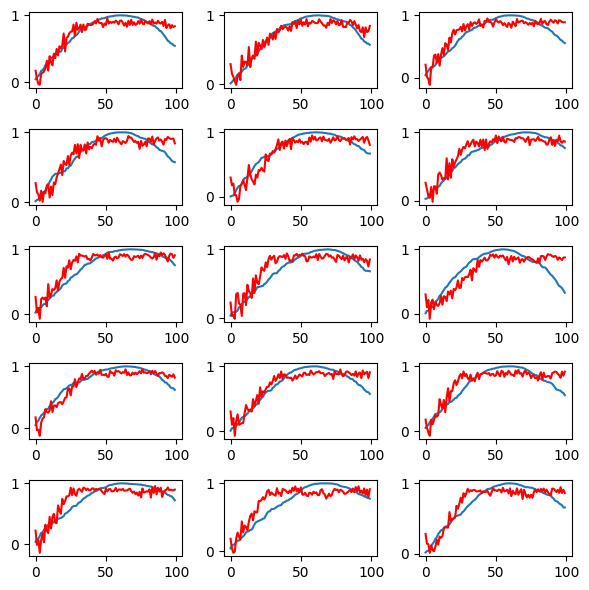

In [7]:
import matplotlib.pyplot as plt

n_rows = 5
n_cols = 3

fig, axs = plt.subplots(n_rows, n_cols, figsize=(6, 6))

ind_selected = np.random.choice(len(X_test), n_rows*n_cols)

# Iterate through the grid and create a subplot in each position
for i in range(n_rows):
    for j in range(n_cols):
        axs[i, j].plot(y_test[ind_selected[i * n_cols + j]].ravel())
        axs[i, j].plot(y_pred[ind_selected[i * n_cols + j]].ravel(), 'r-')

plt.tight_layout()
plt.show()


In [8]:
from tensorflow.keras.layers import LSTM

# Define model architecture
model_lstm = Sequential([
    LSTM(20, return_sequences=True, input_shape=(None, 1)),  
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mean_squared_error')
model_lstm.summary()

# Train the model
model_lstm.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, None, 20)       │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, None, 1)        │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,781 (6.96 KB)

 Trainable params: 1,781 (6.96 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3647
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0351
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0198
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0122
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0106
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0103
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0103
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0101
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0099
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0099
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0074
Epoch 12/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0029
Epoch 13/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0023
Epoch 14/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0014
Epoch 15/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.8320e-04
Epoch 16/50
50/

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


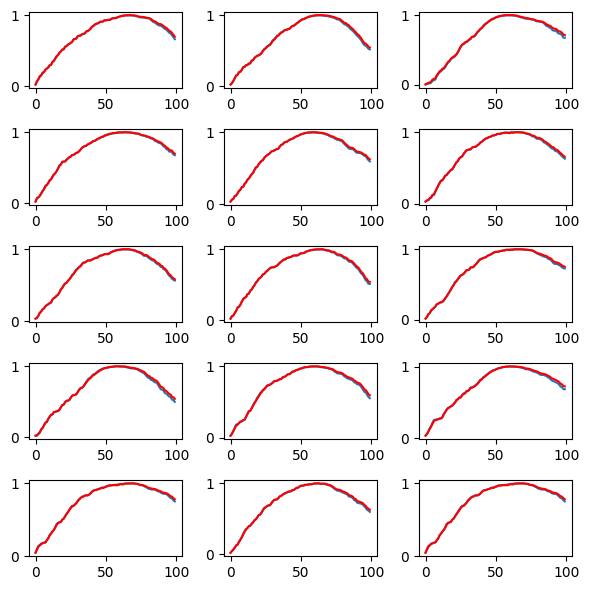

In [9]:
# Test the model 
y_pred_lstm = model_lstm.predict(X_test)

n_rows = 5
n_cols = 3

fig, axs = plt.subplots(n_rows, n_cols, figsize=(6, 6))

ind_selected = np.random.choice(len(X_test), n_rows*n_cols)

# Iterate through the grid and create a subplot in each position
for i in range(n_rows):
    for j in range(n_cols):
        axs[i, j].plot(y_test[ind_selected[i * n_cols + j]].ravel())
        axs[i, j].plot(y_pred_lstm[ind_selected[i * n_cols + j]].ravel(), 'r-')

plt.tight_layout()
plt.show()
